# Import library

In [7]:
from notworLeUtils.notworle_utils.dataset import FolderImage
from notworLeUtils.notworle_utils.matplotlib import draw_plot
from facenet_pytorch import MTCNN, InceptionResnetV1
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision.transforms import ToTensor, Compose, Normalize
import cv2
import pandas as pd

# Set GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Data collection

Location of dataset: D:\gitvanhub\Computer_vision_intergration\dataset\do_mi_xi\raw
Total images: 13


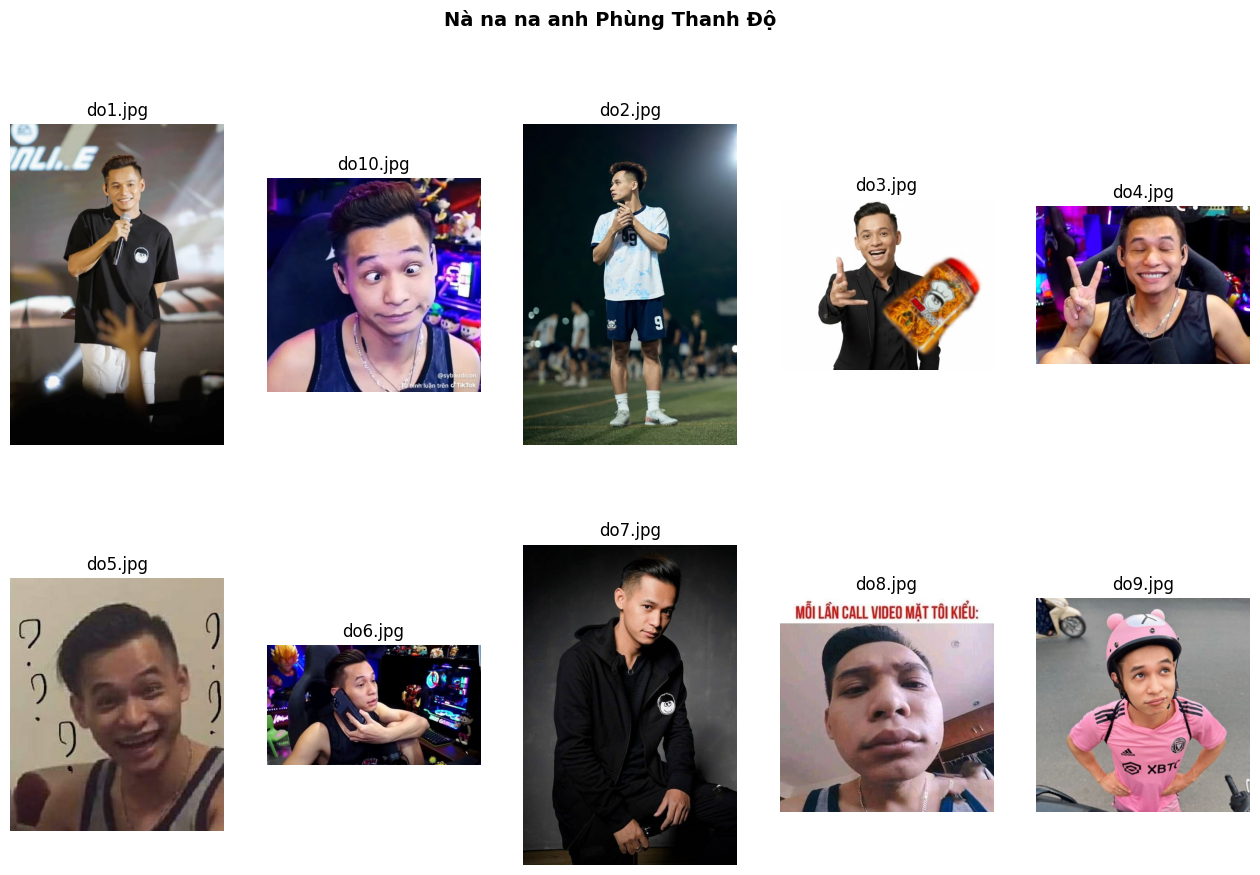

In [8]:
dataset_path = (Path.cwd() / ".." / ".." / "dataset" / "do_mi_xi" / "raw").resolve()
print(f"Location of dataset: {dataset_path}")

domixi_dataset = FolderImage(dataset_path)
print(f"Total images: {len(domixi_dataset)}")

fig, axes = plt.subplots(2, 5, figsize=(16,10))

titles = []
images = []
for image, name, path in domixi_dataset:
    titles.append(name)
    images.append(image)


draw_plot(axes, titles, images, fig_title="Nà na na anh Phùng Thanh Độ")
plt.show()

# Face detection

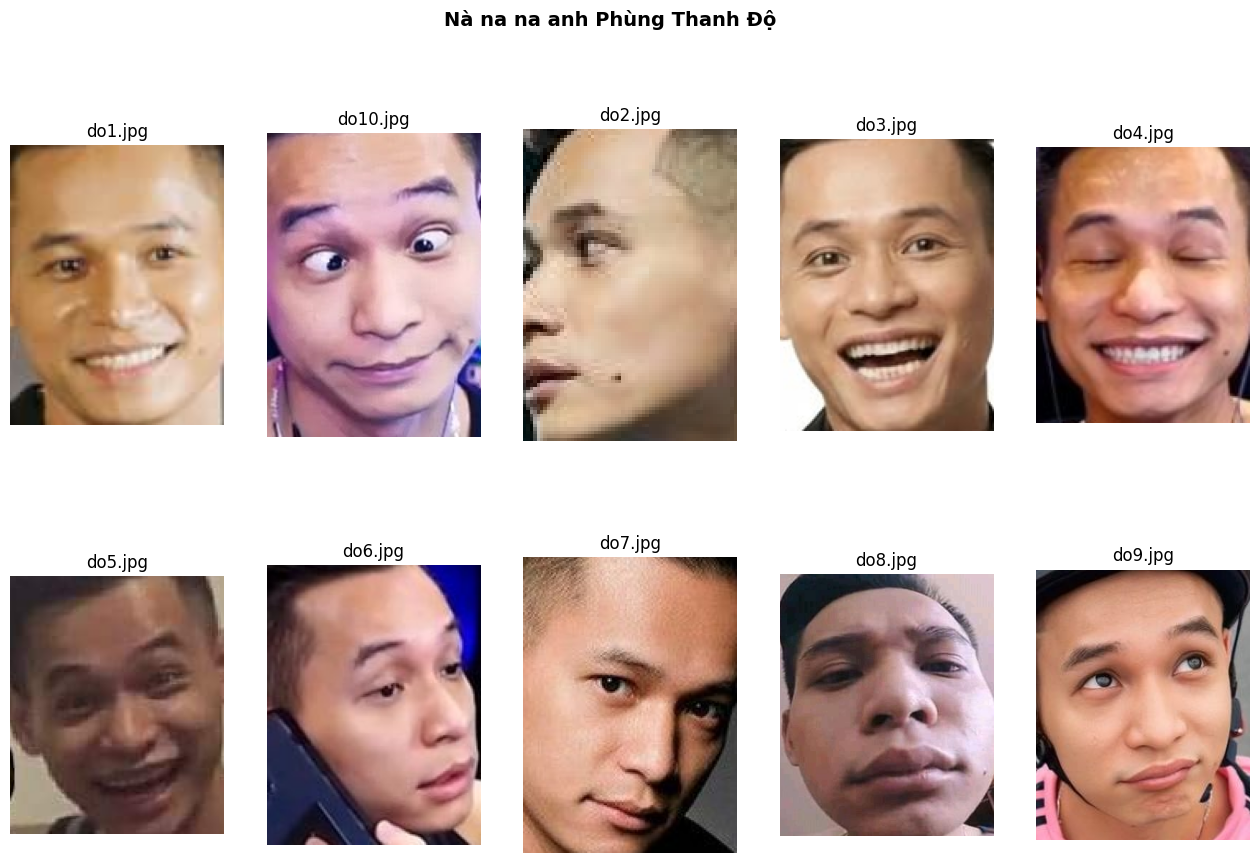

In [9]:
detector_mtcnn = MTCNN(device=device)

titles = []
face_images = []
for image, name, path in domixi_dataset:
    titles.append(name)
    images.append(image)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    faces, probs = detector_mtcnn.detect(image_rgb)
    for face, prob in zip(faces, probs):
        # Each element is an "object" type then we should convert to integer
        x1, y1, x2, y2 = [int(x) for x in face]
        face_resize = image[y1:y2, x1:x2]
        face_images.append(face_resize)

n_col = 5

fig, axes = plt.subplots(len(face_images) // n_col, n_col, figsize=(16,10))

draw_plot(axes, titles, face_images, fig_title="Nà na na anh Phùng Thanh Độ")
plt.show()

# Embedding faces
## Preprocessing

In [10]:
transform = Compose([
    ToTensor(),
    Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

face_images = [transform(cv2.resize(face, (160, 160)))for face in face_images]
for i in range(5):
    print(face_images[i].shape, face_images[i].min(), face_images[i].max())

torch.Size([3, 160, 160]) tensor(-1.) tensor(1.)
torch.Size([3, 160, 160]) tensor(-1.) tensor(1.)
torch.Size([3, 160, 160]) tensor(-1.) tensor(0.9373)
torch.Size([3, 160, 160]) tensor(-1.) tensor(1.)
torch.Size([3, 160, 160]) tensor(-1.) tensor(1.)


## Embedding

In [12]:
resnet  = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# Resnet expected batch, convert with stack
face_images_batch = torch.stack(face_images).to(device)
embedding_face = resnet(face_images_batch).detach().cpu()

cos_sim = [[F.cosine_similarity(face1, face2, dim=0) for face2 in embedding_face] for face1 in embedding_face]
df = pd.DataFrame(cos_sim)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,tensor(1.0000),tensor(0.6273),tensor(0.5443),tensor(0.8302),tensor(0.7386),tensor(0.7256),tensor(0.6514),tensor(0.7918),tensor(0.4286),tensor(0.7026),tensor(0.6402),tensor(0.5797),tensor(0.8039),tensor(-0.0810)
1,tensor(0.6273),tensor(1.),tensor(0.5509),tensor(0.6334),tensor(0.7800),tensor(0.6920),tensor(0.7557),tensor(0.5748),tensor(0.4152),tensor(0.7186),tensor(0.6518),tensor(0.4654),tensor(0.6207),tensor(-0.0681)
2,tensor(0.5443),tensor(0.5509),tensor(1.),tensor(0.5777),tensor(0.6706),tensor(0.5874),tensor(0.5399),tensor(0.5789),tensor(0.5293),tensor(0.6731),tensor(0.3886),tensor(0.5448),tensor(0.5626),tensor(-0.1595)
3,tensor(0.8302),tensor(0.6334),tensor(0.5777),tensor(1.0000),tensor(0.7274),tensor(0.7484),tensor(0.7015),tensor(0.6993),tensor(0.3115),tensor(0.7392),tensor(0.5805),tensor(0.5787),tensor(0.7829),tensor(-0.0548)
4,tensor(0.7386),tensor(0.7800),tensor(0.6706),tensor(0.7274),tensor(1.0000),tensor(0.8068),tensor(0.8313),tensor(0.6600),tensor(0.5619),tensor(0.7465),tensor(0.6165),tensor(0.5857),tensor(0.6497),tensor(-0.0100)
5,tensor(0.7256),tensor(0.6920),tensor(0.5874),tensor(0.7484),tensor(0.8068),tensor(1.0000),tensor(0.7609),tensor(0.6767),tensor(0.5204),tensor(0.7418),tensor(0.4908),tensor(0.6825),tensor(0.7412),tensor(-0.0662)
6,tensor(0.6514),tensor(0.7557),tensor(0.5399),tensor(0.7015),tensor(0.8313),tensor(0.7609),tensor(1.0000),tensor(0.5990),tensor(0.4448),tensor(0.7518),tensor(0.5168),tensor(0.6730),tensor(0.6175),tensor(0.0590)
7,tensor(0.7918),tensor(0.5748),tensor(0.5789),tensor(0.6993),tensor(0.6600),tensor(0.6767),tensor(0.5990),tensor(1.0000),tensor(0.4301),tensor(0.5571),tensor(0.6029),tensor(0.6508),tensor(0.7783),tensor(-0.0958)
8,tensor(0.4286),tensor(0.4152),tensor(0.5293),tensor(0.3115),tensor(0.5619),tensor(0.5204),tensor(0.4448),tensor(0.4301),tensor(1.0000),tensor(0.4522),tensor(0.3692),tensor(0.3950),tensor(0.4908),tensor(-0.0766)
9,tensor(0.7026),tensor(0.7186),tensor(0.6731),tensor(0.7392),tensor(0.7465),tensor(0.7418),tensor(0.7518),tensor(0.5571),tensor(0.4522),tensor(1.),tensor(0.4782),tensor(0.6068),tensor(0.6700),tensor(-0.1531)
